Model Accuracy: 0.8044692737430168


/tmp/ipykernel_596/794335253.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=data, palette='coolwarm')


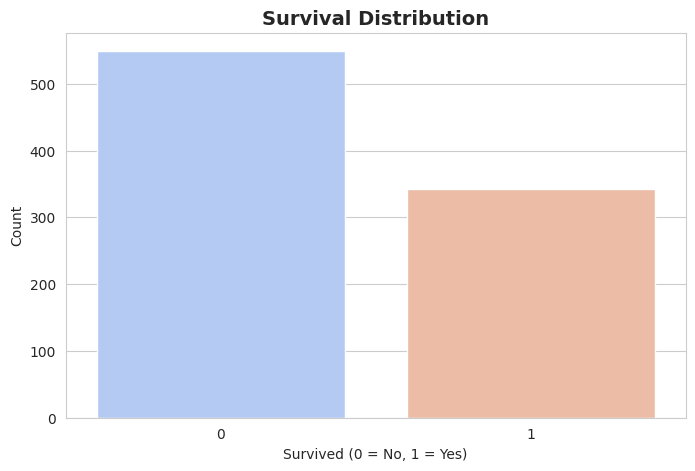

/tmp/ipykernel_596/794335253.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=data, palette='Set2')


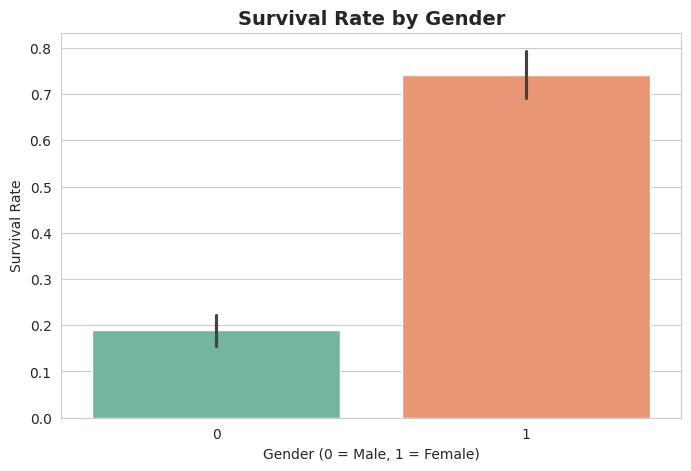

/tmp/ipykernel_596/794335253.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=data, palette='viridis')


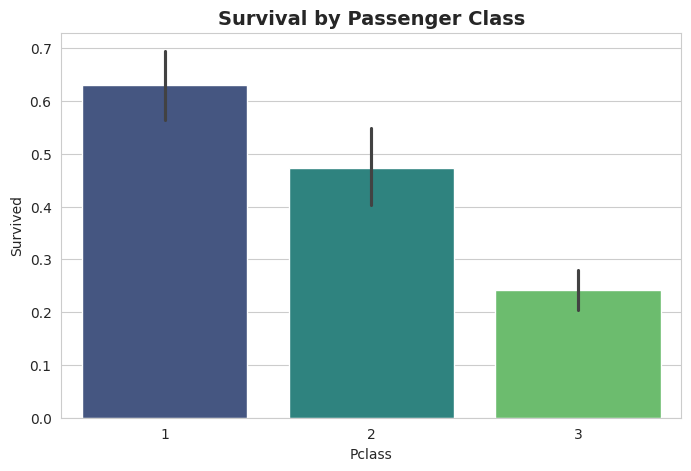

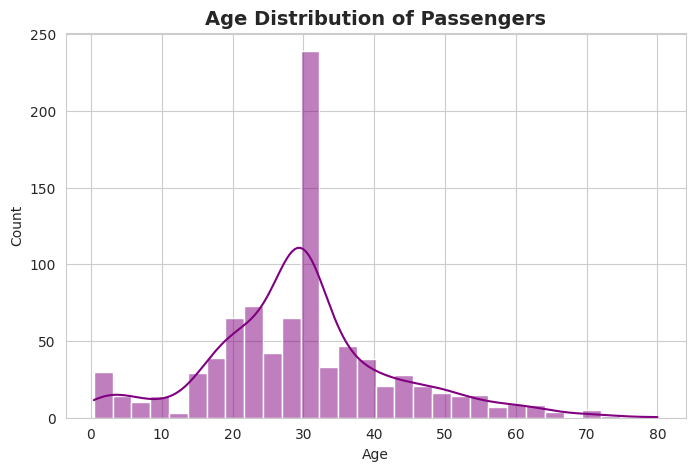

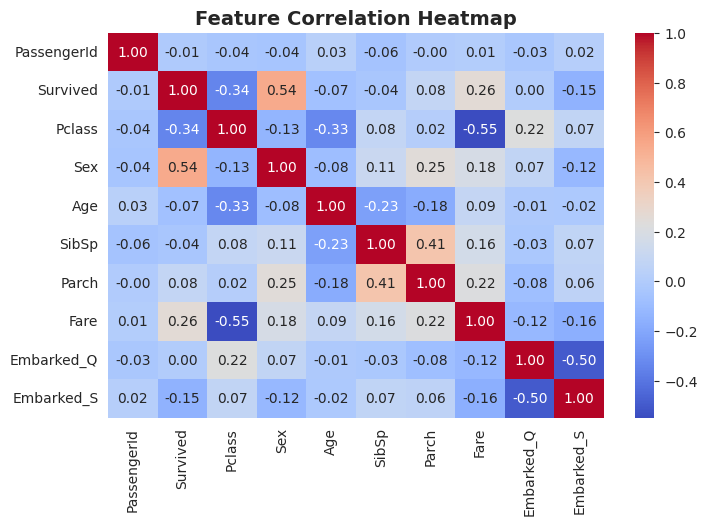

In [ ]:
# ===============================
# Titanic Survival Prediction (Enhanced)
# ===============================

# Step 1: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Style (IMPORTANT for attractive graphs)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# Step 2: Load dataset
data = pd.read_csv("Titanic-Dataset.csv")

# Step 3: Data Cleaning
data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

data = data.drop(['Name', 'Ticket', 'Cabin'], axis=1)

# Step 4: Split data
from sklearn.model_selection import train_test_split

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 6: Accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 🔥 ATTRACTIVE VISUALIZATIONS
# ===============================

# 1. Survival Count (Better Style)
sns.countplot(x='Survived', data=data, palette='coolwarm')
plt.title("Survival Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# 2. Gender vs Survival
sns.barplot(x='Sex', y='Survived', data=data, palette='Set2')
plt.title("Survival Rate by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender (0 = Male, 1 = Female)")
plt.ylabel("Survival Rate")
plt.show()

# 3. Passenger Class vs Survival
sns.barplot(x='Pclass', y='Survived', data=data, palette='viridis')
plt.title("Survival by Passenger Class", fontsize=14, fontweight='bold')
plt.show()

# 4. Age Distribution
sns.histplot(data['Age'], bins=30, kde=True, color='purple')
plt.title("Age Distribution of Passengers", fontsize=14, fontweight='bold')
plt.show()

# 5. Heatmap (Very Impressive)
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()